In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import shutil
import string
from sklearn.metrics import classification_report
import tensorflow as tf
from keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.layers import Dense, Input, Dropout, Bidirectional, LSTM, Embedding, BatchNormalization,  Reshape, Conv2D, MaxPool2D, concatenate, Flatten, Activation
import torch
import numpy as np
from transformers import BertTokenizer, BertModel,RobertaTokenizer, RobertaModel,AutoTokenizer, AutoModel
import ast

In [ ]:
# Verificar si la GPU está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
archivo_3 = '/content/drive/MyDrive/UDENAR/ProyectosGrado/Errol/Ginna/ResultsGraph//DataProgramsandDescriptions-CatRetroalimentacion5000.xlsx'
train_full = pd.read_excel(archivo_3)

In [ ]:
train_full

,No.,Problema,Solución,Estado incial,Estado final,Transformación de estado,Etiqueta 1,Etiqueta 2,Realimentación
0,1,Write a Python function that returns the facto...,def factorial(n):\n result = 1\n i = 1\n...,"result = 1, i = 1",i <= n,"result *= i, i += 1",Correct,['Correct'],NaN
1,2,Write a Python function that returns the sum o...,def sum_1_to_100():\n total = 0\n i = 1\...,"total = 0, i = 1, n = 100",i <= n,"total += i, i += 1",Correct,['Correct'],NaN
2,3,Write a Python function that prints the number...,def print_and_store():\n numbers = []\n ...,"numbers = [], i = 0, n = 10",i <= n,"print(i), numbers.append(i), i += 1",Correct,['Correct'],NaN
3,4,Write a Python function to print the numbers f...,def print_and_store_reverse():\n numbers = ...,"numbers = [], i = 10, n = 1",i >= n,"print(i), numbers.append(i), i -= 1",Correct,['Correct'],NaN
4,5,Write a Python function to check if a number i...,def is_prime(num):\n if num <= 1:\n ...,"i = 2, i = = 0:",i <= num//2,"if num % i == 0:, return False, i += 1",Correct,['Correct'],NaN
...,...,...,...,...,...,...,...,...,...
4995,4996,Write a Python function that returns the sum o...,def sum_of_first_five_numbers():\n number =...,"number = 1, total_sum = 0, count = 1, total_su...",count < 5,"total_sum = total_sum + number, count = count - 1",Incorrect,"['Initial state', 'Final state']",NaN
4996,4997,Write a Python function that returns the facto...,def factorial(n):\n result = 0\n i = 0\n...,"result = 0, i = 0",i < n,"result *= i, i += 1",Incorrect,"['Initial state', 'Final state']",NaN
4997,4998,Write a Python function that prints the number...,def print_and_store_numbers():\n numbers = ...,"numbers = [], n = 1",n <= 11,"print(n), numbers.append(n), n += 1",Incorrect,"['Initial state', 'Final state']",NaN
4998,4999,Write a Python function to print the numbers f...,def print_and_store_numbers():\n numbers = ...,"numbers = [], n = 9",n >= 0,"print(n), numbers.append(n), n -= 1",Incorrect,"['Initial state', 'Final state']",NaN


# AST spliter D. Gries form

In [ ]:
class WhileLoopFinder(ast.NodeVisitor):
    def __init__(self, source_code):
        self.source_code = source_code.splitlines()
        self.functions_with_while = []
        self.current_function = None

    def visit_FunctionDef(self, node):
        original_current_function = self.current_function
        self.current_function = {
            "function_name": node.name,
            "has_while_loop": False,
            "pre_while_code_lines": [],
            "while_loops": []
        }

        function_start_line = node.lineno - 1
        function_end_line = (node.end_lineno if hasattr(node, 'end_lineno') else len(self.source_code))
        function_lines = self.source_code[function_start_line:function_end_line]

        found_while = False
        for stmt in node.body:
            if isinstance(stmt, ast.While):
                self.current_function["has_while_loop"] = True
                found_while = True
                try:
                    while_condition = ast.unparse(stmt.test).strip()
                    print("OK condition")
                except AttributeError:
                    print("Error al obtener la condición del while")
                try:
                    while_body_code = ast.unparse(ast.Module(body=stmt.body, type_ignores=[])).strip()
                    print("Ok body")
                except AttributeError:
                    print("Error al obtener el código del cuerpo del while")

                self.current_function["while_loops"].append({
                    "condition": while_condition,
                    "body_code": while_body_code
                })
            elif not found_while:
                start_line = stmt.lineno - 1
                end_line = (stmt.end_lineno if hasattr(stmt, 'end_lineno') else stmt.lineno)
                self.current_function["pre_while_code_lines"].extend(self.source_code[start_line:end_line])
            self.generic_visit(stmt)

        if self.current_function["has_while_loop"]:
            last_while_end_line = None
            if self.current_function["while_loops"]:
                last_while_node = next((node for node in reversed(node.body) if isinstance(node, ast.While)), None)
                if last_while_node and hasattr(last_while_node, 'end_lineno'):
                    last_while_end_line = last_while_node.end_lineno
            post_while_code_lines = []
            if last_while_end_line:
                function_indent = len(self.source_code[node.lineno - 1]) - len(self.source_code[node.lineno - 1].lstrip())
                for line in self.source_code[last_while_end_line:function_end_line]:
                    if line.startswith(self.source_code[node.lineno - 1][:function_indent] + "    "):
                        post_while_code_lines.append(line[function_indent + 4:])
                    else:
                        post_while_code_lines.append(line[function_indent:])
            self.current_function["post_while_code_lines"] = "\n".join(post_while_code_lines).strip()
            self.current_function["pre_while_code_lines"] = "\n".join(self.current_function["pre_while_code_lines"]).strip()
            self.functions_with_while.append(self.current_function)

        self.current_function = original_current_function



In [ ]:
def DGries_states(solution):
  try:
    # Crear el AST
    tree = ast.parse(solution)
    # Recorrer el AST con nuestro visitante
    finder = WhileLoopFinder(solution)
    finder.visit(tree)
    for func_info in finder.functions_with_while:
      initial_state=func_info["pre_while_code_lines"] if func_info["pre_while_code_lines"] else False
      end_state=""
      transformation_state=""
      for j, wl in enumerate(func_info["while_loops"]):
          end_state=wl["condition"]
          transformation_state=wl["body_code"]

      if not initial_state:
        initial_state=transformation_state
      return initial_state,transformation_state,end_state
  except Exception as error:
    return "Exception:"+str(error),"Exception:"+str(error),"Exception:"+str(error)




# Encoder Description and Code

In [ ]:
class Encoder:
  def __init__(self):
    self.is_loadtokenizers=False



  def tokenize_and_generate_embeddings_descriptions(self,description):
    if not self.is_loadtokenizers:
      raise ValueError("tokenizers dont load")
    # Tokenize input description and move tokens to GPU
    tokens = self.beart_tokenizer.encode_plus(description, return_tensors="pt", truncation=True)
    tokens = {key: value.to(device) for key, value in tokens.items()}
    # Generate embeddings
    with torch.no_grad():
        outputs = self.beart_model(**tokens)
    # Extract embeddings for all tokens
    desc_embeddings = outputs.last_hidden_state.cpu().numpy()
    return desc_embeddings

  def tokenize_and_generate_embeddings_codes(self,code):
    if not self.is_loadtokenizers:
      raise ValueError("tokenizers dont load")
    # Tokenize input code and move tokens to GPU
    tokens = self.codebeart_tokenizer.encode_plus(code, return_tensors="pt", truncation=True)
    tokens = {key: value.to(device) for key, value in tokens.items()}
    # Generate embeddings
    with torch.no_grad():
        outputs = self.codebeart_model(**tokens)
    # Extract embeddings for all tokens
    code_embeddings = outputs.last_hidden_state.cpu().numpy()

    return code_embeddings


  def tokenize_and_generate_embeddings_graphcodes(self,code):
    if not self.is_loadtokenizers:
      raise ValueError("tokenizers dont load")
    # Tokenize input code and move tokens to GPU
    tokens = self.graphcodebert_tokenizer.encode_plus(code, return_tensors="pt", truncation=True)
    tokens = {key: value.to(device) for key, value in tokens.items()}
    # Generate embeddings
    with torch.no_grad():
        outputs = self.graphcodebert_model(**tokens)
    # Extract embeddings for all tokens
    code_embeddings = outputs.last_hidden_state.cpu().numpy()
    return code_embeddings

  def load_beart_tokenizer(self):
    # Verificar si la GPU está disponible
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Cargar el tokenizer y el modelo en la GPU si está disponible
    model_name = "bert-base-uncased"
    self.beart_model = BertModel.from_pretrained(model_name)
    self.beart_tokenizer = BertTokenizer.from_pretrained(model_name)
    self.beart_model.to(device)

  def load_graphcodebert_tokenizer(self):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.graphcodebert_tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
    self.graphcodebert_model = AutoModel.from_pretrained("microsoft/graphcodebert-base")
    self.graphcodebert_model.to(device)


  def load_codebert_tokenizer(self):
    # Verificar si la GPU está disponible
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Cargar el tokenizer y el modelo en la GPU si está disponible
    self.codebeart_tokenizer = RobertaTokenizer.from_pretrained("microsoft/codebert-base")
    self.codebeart_model = RobertaModel.from_pretrained("microsoft/codebert-base")
    self.codebeart_model.to(device)

  def start_tokenizer(self):
    self.load_beart_tokenizer()
    #self.load_codebert_tokenizer()
    self.load_graphcodebert_tokenizer()
    self.is_loadtokenizers=True




# All characteristics

In [ ]:
def categoricallabelAll(w):

  if w=="['Initial state']":
    return 0
  if w=="['Final state']":
    return 1
  if w=="['State transformation']":
    return 2
  if w=="['Initial state', 'Final state']":
    return 3
  if w=="['Initial state', 'State transformation']":
    return 4
  if w=="['Final state', 'State transformation']":
    return 5
  if w=="['Initial state', 'Final state', 'State transformation']":
    return 6
  return 7

category=np.array([
    'Initial state',
    'Final state',
    'State transformation',
    'Initial state, Final state',
    'Initial state, State transformation',
    'Final state, State transformation',
    'Initial state, Final state, State transformation'

])

In [ ]:
train_full.drop(["No.","Realimentación","Estado incial","Estado final","Transformación de estado"],axis=1,inplace=True)
train_full

,Problema,Solución,Etiqueta 1,Etiqueta 2
0,Write a Python function that returns the facto...,def factorial(n):\n result = 1\n i = 1\n...,Correct,['Correct']
1,Write a Python function that returns the sum o...,def sum_1_to_100():\n total = 0\n i = 1\...,Correct,['Correct']
2,Write a Python function that prints the number...,def print_and_store():\n numbers = []\n ...,Correct,['Correct']
3,Write a Python function to print the numbers f...,def print_and_store_reverse():\n numbers = ...,Correct,['Correct']
4,Write a Python function to check if a number i...,def is_prime(num):\n if num <= 1:\n ...,Correct,['Correct']
...,...,...,...,...
4995,Write a Python function that returns the sum o...,def sum_of_first_five_numbers():\n number =...,Incorrect,"['Initial state', 'Final state']"
4996,Write a Python function that returns the facto...,def factorial(n):\n result = 0\n i = 0\n...,Incorrect,"['Initial state', 'Final state']"
4997,Write a Python function that prints the number...,def print_and_store_numbers():\n numbers = ...,Incorrect,"['Initial state', 'Final state']"
4998,Write a Python function to print the numbers f...,def print_and_store_numbers():\n numbers = ...,Incorrect,"['Initial state', 'Final state']"


In [ ]:
train_full[["Estado incial","Transformación de estado","Estado final"]]=train_full['Solución'].apply(DGries_states).apply(pd.Series)

Streaming output truncated to the last 5000 lines.
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK condition
Ok body
OK c

In [ ]:
train_full

,Problema,Solución,Etiqueta 1,Etiqueta 2,Estado incial,Transformación de estado,Estado final
0,Write a Python function that returns the facto...,def factorial(n):\n result = 1\n i = 1\n...,Correct,['Correct'],result = 1\n i = 1,result *= i\ni += 1,i <= n
1,Write a Python function that returns the sum o...,def sum_1_to_100():\n total = 0\n i = 1\...,Correct,['Correct'],total = 0\n i = 1\n n = 100,total += i\ni += 1,i <= n
2,Write a Python function that prints the number...,def print_and_store():\n numbers = []\n ...,Correct,['Correct'],numbers = []\n i = 0\n n = 10,print(i)\nnumbers.append(i)\ni += 1,i <= n
3,Write a Python function to print the numbers f...,def print_and_store_reverse():\n numbers = ...,Correct,['Correct'],numbers = []\n i = 10\n n = 1,print(i)\nnumbers.append(i)\ni -= 1,i >= n
4,Write a Python function to check if a number i...,def is_prime(num):\n if num <= 1:\n ...,Correct,['Correct'],if num <= 1:\n return False\n i = 2,if num % i == 0:\n return False\ni += 1,i <= num // 2
...,...,...,...,...,...,...,...
4995,Write a Python function that returns the sum o...,def sum_of_first_five_numbers():\n number =...,Incorrect,"['Initial state', 'Final state']",number = 1\n total_sum = 0\n count = 1,total_sum = total_sum + number\ncount = count - 1,count < 5
4996,Write a Python function that returns the facto...,def factorial(n):\n result = 0\n i = 0\n...,Incorrect,"['Initial state', 'Final state']",result = 0\n i = 0,result *= i\ni += 1,i < n
4997,Write a Python function that prints the number...,def print_and_store_numbers():\n numbers = ...,Incorrect,"['Initial state', 'Final state']",numbers = []\n n = 1,print(n)\nnumbers.append(n)\nn += 1,n <= 11
4998,Write a Python function to print the numbers f...,def print_and_store_numbers():\n numbers = ...,Incorrect,"['Initial state', 'Final state']",numbers = []\n n = 9,print(n)\nnumbers.append(n)\nn -= 1,n >= 0


In [ ]:
train_full = train_full[train_full['Etiqueta 1']!='Correct'].copy()

In [ ]:
train_full.dropna(inplace=True)

In [ ]:
train_full

,Problema,Solución,Etiqueta 1,Etiqueta 2,Estado incial,Transformación de estado,Estado final
280,Write a Python function that returns the facto...,def factorial(n):\n result = 0\n i = 1\n...,Incorrect,['Initial state'],result = 0\n i = 1,result += i\ni += 1,i <= n
281,Write a Python function that returns the sum o...,def sum_1_to_100():\n total = 0\n i = 1\...,Incorrect,['Initial state'],total = 0\n i = 1,total += i\ni += 2,i < 100
282,Write a Python function that prints the number...,def print_and_store():\n numbers = []\n ...,Incorrect,['Initial state'],numbers = []\n i = 0,print(i)\nnumbers[i] = i\ni += 1,i < 10
283,Write a Python function to print the numbers f...,def print_and_store_reverse():\n numbers = ...,Incorrect,['Initial state'],numbers = []\n i = 0,print(10 - i)\nnumbers.append(i)\ni += 1,i < 10
284,Write a Python function to check if a number i...,def is_prime(num):\n i = 2\n while i < n...,Incorrect,['Initial state'],i = 2,if num % i == 0:\n return False\ni += 1,i < num
...,...,...,...,...,...,...,...
4995,Write a Python function that returns the sum o...,def sum_of_first_five_numbers():\n number =...,Incorrect,"['Initial state', 'Final state']",number = 1\n total_sum = 0\n count = 1,total_sum = total_sum + number\ncount = count - 1,count < 5
4996,Write a Python function that returns the facto...,def factorial(n):\n result = 0\n i = 0\n...,Incorrect,"['Initial state', 'Final state']",result = 0\n i = 0,result *= i\ni += 1,i < n
4997,Write a Python function that prints the number...,def print_and_store_numbers():\n numbers = ...,Incorrect,"['Initial state', 'Final state']",numbers = []\n n = 1,print(n)\nnumbers.append(n)\nn += 1,n <= 11
4998,Write a Python function to print the numbers f...,def print_and_store_numbers():\n numbers = ...,Incorrect,"['Initial state', 'Final state']",numbers = []\n n = 9,print(n)\nnumbers.append(n)\nn -= 1,n >= 0


In [ ]:
encoder=Encoder()
encoder.start_tokenizer()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
%%time
problem=train_full['Problema'].apply(encoder.tokenize_and_generate_embeddings_descriptions).to_numpy()
code=train_full['Solución'].apply(encoder.tokenize_and_generate_embeddings_graphcodes).to_numpy()
startstate = train_full['Estado incial'].apply(encoder.tokenize_and_generate_embeddings_graphcodes).to_numpy()
finalstate = train_full['Estado final'].apply(encoder.tokenize_and_generate_embeddings_graphcodes).to_numpy()
transstate = train_full['Transformación de estado'].apply(encoder.tokenize_and_generate_embeddings_graphcodes).to_numpy()

CPU times: user 2min 58s, sys: 3.04 s, total: 3min 1s
Wall time: 3min 57s


In [ ]:
problem.shape,code.shape,startstate.shape,finalstate.shape,transstate.shape

((3459,), (3459,), (3459,), (3459,), (3459,))

In [ ]:
print(startstate.shape)
print(startstate[1262].shape)


(3459,)
(1, 13, 768)


In [ ]:
Xp=np.array([sentence[0].mean(axis=0) for sentence in problem])
Xcode=np.array([sentence[0].mean(axis=0) for sentence in code])
Xs=np.array([sentence[0].mean(axis=0) for sentence in startstate])
Xf=np.array([sentence[0].mean(axis=0) for sentence in finalstate])
Xt=np.array([sentence[0].mean(axis=0) for sentence in transstate])
Xp.shape,Xs.shape,Xf.shape,Xt.shape

((3459, 768), (3459, 768), (3459, 768), (3459, 768))

In [ ]:
y=train_full['Etiqueta 2'].apply(categoricallabelAll)
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6])

In [ ]:
from sklearn.model_selection import train_test_split

Xp_train,Xp_test,Xcode_train,Xcode_test,Xs_train,Xs_test,Xt_train,Xt_test,Xf_train,Xf_test,y_train,y_test=train_test_split(Xp,Xcode,Xs,Xt,Xf,y,test_size=0.2,random_state=2023, stratify=y)

In [ ]:
Xp_train.shape,Xp_test.shape,Xcode_train.shape, Xcode_test.shape, Xs_train.shape,Xs_test.shape,Xt_train.shape,Xt_test.shape,Xf_train.shape,Xf_test.shape,y_train.shape,y_test.shape

((2767, 768),
 (692, 768),
 (2767, 768),
 (692, 768),
 (2767, 768),
 (692, 768),
 (2767, 768),
 (692, 768),
 (2767, 768),
 (692, 768),
 (2767,),
 (692,))

# Keras model

In [ ]:
from tensorflow.keras import backend as K
import gc
def ANNTC(input,base,pow_initial,num_max_blocks):

  drop_out=0.5
  print("base",base,"pow",pow_initial,"num_max_blocks",num_max_blocks)
  n=num_max_blocks//2
  neurons=int(base**(pow_initial+n+1))
  # Encoder
  x=None
  print("Encoder",n)
  try:
    for i in range(n):
      x=Dense(neurons)(input)
      x=BatchNormalization()(x)
      x=Activation('relu')(x)
      x=Dropout(drop_out)(x)
      input=x
      drop_out=0.2
      print("Block ",i,neurons)
      neurons=int(neurons/base)



    #BottleNeck
    x=Dense(neurons)(x)
    x=BatchNormalization()(x)
    x=Activation('relu')(x)
    x=Dropout(0.2)(x)
    print("BottleNeck",neurons)

    # Decoder
    print("Decoder",n)
    for i in range(n):
      neurons=int(neurons*base)
      print("Block ",i,neurons)
      x=Dense(neurons)(x)
      x=BatchNormalization()(x)
      x=Activation('relu')(x)
      x=Dropout(drop_out)(x)
      if i==n-1:
        drop_out=0.5
      drop_out=0.2
  except Exception as err:

    K.clear_session()
    gc.collect()
    del x
    print(f"Unexpected {err=}, {type(err)=}")
    raise

  return x

def neural_network_all(problem,code,start_input,trass_input,final_input,base=10,pow_initial=4,num_max_blocks=3):
  mlp_p=ANNTC(problem,base,pow_initial,num_max_blocks)
  mlp_code=ANNTC(code,base,pow_initial,num_max_blocks)
  mlp_s=ANNTC(start_input,base,pow_initial,num_max_blocks)
  mlp_t=ANNTC(trass_input,base,pow_initial,num_max_blocks)
  mlp_f=ANNTC(final_input,base,pow_initial,num_max_blocks)
  ## Concatenate All models
  combined = concatenate([mlp_p,mlp_code ,mlp_s, mlp_t,mlp_f])
  ## output layer
  output=Dense(8)(combined)
  output=BatchNormalization()(output)
  output=Activation('softmax')(output)
  ## Model
  model = Model(inputs=[problem_input,code,start_input, trass_input,final_input], outputs=output)
  return model


def neural_network_code_gries(code_input,start_input,trass_input,final_input,base=10,pow_initial=4,num_max_blocks=3):
  mlp_code=ANNTC(code_input,base,pow_initial,num_max_blocks)
  mlp_s=ANNTC(start_input,base,pow_initial,num_max_blocks)
  mlp_t=ANNTC(trass_input,base,pow_initial,num_max_blocks)
  mlp_f=ANNTC(final_input,base,pow_initial,num_max_blocks)
  ## Concatenate All models
  combined = concatenate([mlp_code, mlp_s, mlp_t,mlp_f])
  ## output layer
  output=Dense(8)(combined)
  output=BatchNormalization()(output)
  output=Activation('softmax')(output)
  ## Model
  model = Model(inputs=[code_input, start_input, trass_input,final_input], outputs=output)
  return model

def neural_network(problem,start_input,trass_input,final_input,base=10,pow_initial=4,num_max_blocks=3):
  mlp_p=ANNTC(problem,base,pow_initial,num_max_blocks)
  mlp_s=ANNTC(start_input,base,pow_initial,num_max_blocks)
  mlp_t=ANNTC(trass_input,base,pow_initial,num_max_blocks)
  mlp_f=ANNTC(final_input,base,pow_initial,num_max_blocks)
  ## Concatenate All models
  combined = concatenate([mlp_p, mlp_s, mlp_t,mlp_f])
  ## output layer
  output=Dense(8)(combined)
  output=BatchNormalization()(output)
  output=Activation('softmax')(output)
  ## Model
  model = Model(inputs=[problem_input, start_input, trass_input,final_input], outputs=output)
  return model


def neural_network_wproblem(start_input,trass_input,final_input,base=10,pow_initial=4,num_max_blocks=3):
  mlp_s=ANNTC(start_input,base,pow_initial,num_max_blocks)
  mlp_t=ANNTC(trass_input,base,pow_initial,num_max_blocks)
  mlp_f=ANNTC(final_input,base,pow_initial,num_max_blocks)
  ## Concatenate All models
  combined = concatenate([mlp_s, mlp_t,mlp_f])
  ## output layer
  output=Dense(8)(combined)
  output=BatchNormalization()(output)
  output=Activation('softmax')(output)
  ## Model
  model = Model(inputs=[start_input, trass_input,final_input], outputs=output)
  return model

def neural_network_problem_code(problem,code_input,base=10,pow_initial=4,num_max_blocks=3):
  mlp_p=ANNTC(problem,base,pow_initial,num_max_blocks)
  mlp_code=ANNTC(code_input,base,pow_initial,num_max_blocks)
  ## Concatenate All models
  combined = concatenate([mlp_p, mlp_code])
  ## output layer
  output=Dense(8)(combined)
  output=BatchNormalization()(output)
  output=Activation('softmax')(output)
  ## Model
  model = Model(inputs=[problem, code_input], outputs=output)
  return model

def neural_network_code(code_input,base=10,pow_initial=4,num_max_blocks=3):

  mlp_code=ANNTC(code_input,base,pow_initial,num_max_blocks)
  ## output layer
  output=Dense(8)(mlp_code)
  output=BatchNormalization()(output)
  output=Activation('softmax')(output)
  ## Model
  model = Model(inputs=[code_input], outputs=output)
  return model

In [ ]:
import numpy as np
np.linspace(5,70,14)


array([ 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65.,
       70.])

In [ ]:
models=[]
models_names=["problemall","problem_gries","code_gries","gries","problem_code","code"]

problem_input=Input((768,))
code_input=Input((768,))
start_input=Input((768,))
trass_input=Input((768,))
final_input=Input((768,))

print("problem all")
models.append(neural_network_all(problem_input,code_input,start_input,trass_input,final_input,base=8,pow_initial=1, num_max_blocks=3))
print("\nproblem gries")
models.append(neural_network(problem_input,start_input,trass_input,final_input,base=8,pow_initial=1, num_max_blocks=3))
print("\ncode gries")
models.append(neural_network_code_gries(code_input,start_input,trass_input,final_input,base=8,pow_initial=1, num_max_blocks=3))
print("\ngries")
models.append(neural_network_wproblem(start_input,trass_input,final_input,base=8,pow_initial=1, num_max_blocks=3))
print("\nproblem code")
models.append(neural_network_problem_code(problem_input,code_input,base=8,pow_initial=1, num_max_blocks=3))
print("\ncode")
models.append(neural_network_code(code_input,base=8,pow_initial=1, num_max_blocks=3))


problem all
base 8 pow 1 num_max_blocks 3
Encoder 1
Block  0 512
BottleNeck 64
Decoder 1
Block  0 512
base 8 pow 1 num_max_blocks 3
Encoder 1
Block  0 512
BottleNeck 64
Decoder 1
Block  0 512
base 8 pow 1 num_max_blocks 3
Encoder 1
Block  0 512
BottleNeck 64
Decoder 1
Block  0 512
base 8 pow 1 num_max_blocks 3
Encoder 1
Block  0 512
BottleNeck 64
Decoder 1
Block  0 512
base 8 pow 1 num_max_blocks 3
Encoder 1
Block  0 512
BottleNeck 64
Decoder 1
Block  0 512

problem gries
base 8 pow 1 num_max_blocks 3
Encoder 1
Block  0 512
BottleNeck 64
Decoder 1
Block  0 512
base 8 pow 1 num_max_blocks 3
Encoder 1
Block  0 512
BottleNeck 64
Decoder 1
Block  0 512
base 8 pow 1 num_max_blocks 3
Encoder 1
Block  0 512
BottleNeck 64
Decoder 1
Block  0 512
base 8 pow 1 num_max_blocks 3
Encoder 1
Block  0 512
BottleNeck 64
Decoder 1
Block  0 512

code gries
base 8 pow 1 num_max_blocks 3
Encoder 1
Block  0 512
BottleNeck 64
Decoder 1
Block  0 512
base 8 pow 1 num_max_blocks 3
Encoder 1
Block  0 512
BottleNe

In [ ]:
def plot_history(history):
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('model loss')
  plt.ylabel('loss')
  plt.xlabel('epoch')
  plt.legend(['train', 'validation'], loc='upper left')
  plt.show()
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('model accuracy')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.legend(['train', 'validation'], loc='upper left')
  plt.show()


problemall
Epoch 1/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 37s 698ms/step - accuracy: 0.2215 - loss: 2.1840 - val_accuracy: 0.3791 - val_loss: 1.9394 - learning_rate: 0.0010
Epoch 2/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4950 - loss: 1.5769 - val_accuracy: 0.4729 - val_loss: 1.8970 - learning_rate: 0.0010
Epoch 3/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6160 - loss: 1.3686 - val_accuracy: 0.6173 - val_loss: 1.8287 - learning_rate: 0.0010
Epoch 4/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7029 - loss: 1.2202 - val_accuracy: 0.5903 - val_loss: 1.7659 - learning_rate: 0.0010
Epoch 5/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7360 - loss: 1.1303 - val_accuracy: 0.6625 - val_loss: 1.6572 - learning_rate: 0.0010
Epoch 6/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7610 - loss: 1.0641 - val_accuracy: 0.7148 - val_loss: 1.5624 - learning_rate: 0.0010
Epoch 7/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.77

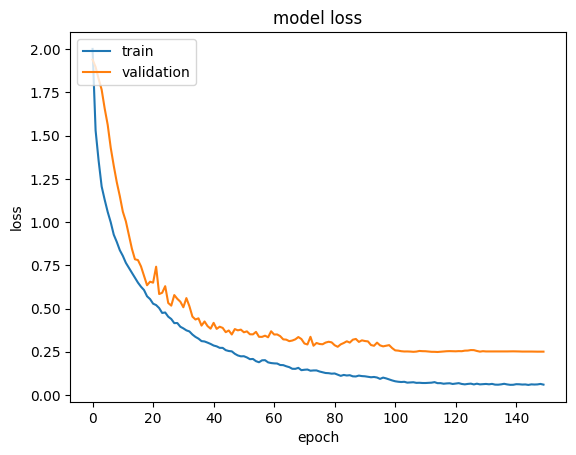

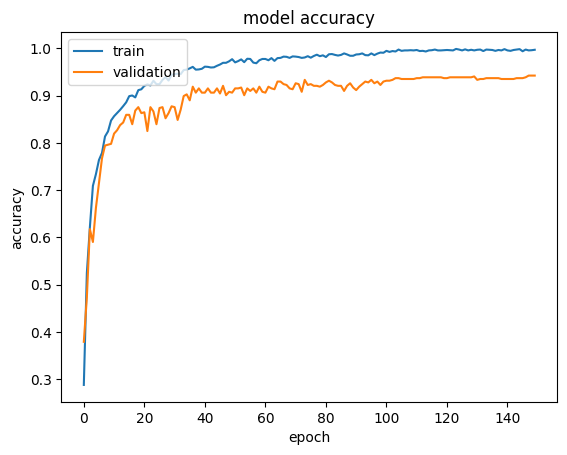

problem_gries
Epoch 1/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 31s 544ms/step - accuracy: 0.2482 - loss: 2.1519 - val_accuracy: 0.4097 - val_loss: 1.8910 - learning_rate: 0.0010
Epoch 2/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4912 - loss: 1.5850 - val_accuracy: 0.5253 - val_loss: 1.8031 - learning_rate: 0.0010
Epoch 3/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6019 - loss: 1.4077 - val_accuracy: 0.6155 - val_loss: 1.7274 - learning_rate: 0.0010
Epoch 4/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6517 - loss: 1.2655 - val_accuracy: 0.7022 - val_loss: 1.6374 - learning_rate: 0.0010
Epoch 5/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7086 - loss: 1.1635 - val_accuracy: 0.7347 - val_loss: 1.5470 - learning_rate: 0.0010
Epoch 6/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7544 - loss: 1.0705 - val_accuracy: 0.7365 - val_loss: 1.4543 - learning_rate: 0.0010
Epoch 7/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0

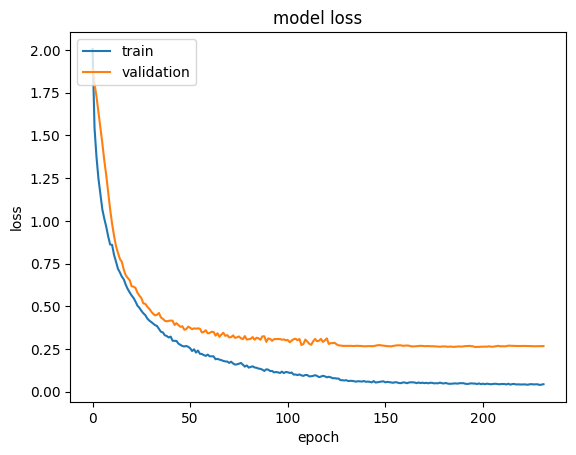

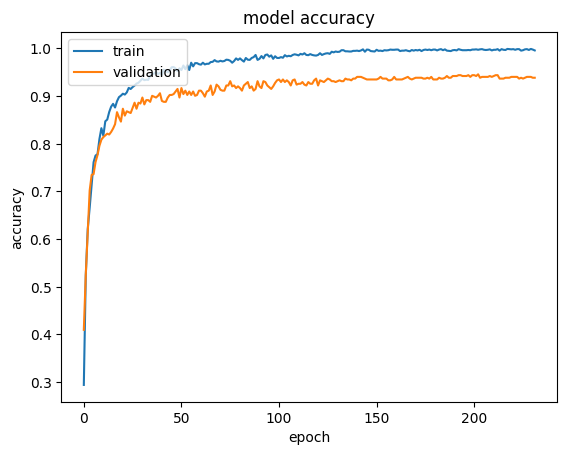

code_gries
Epoch 1/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 560ms/step - accuracy: 0.2260 - loss: 2.1662 - val_accuracy: 0.4224 - val_loss: 1.9061 - learning_rate: 0.0010
Epoch 2/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5026 - loss: 1.5713 - val_accuracy: 0.4440 - val_loss: 1.8997 - learning_rate: 0.0010
Epoch 3/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6062 - loss: 1.3732 - val_accuracy: 0.4874 - val_loss: 1.8663 - learning_rate: 0.0010
Epoch 4/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6911 - loss: 1.2252 - val_accuracy: 0.5235 - val_loss: 1.8145 - learning_rate: 0.0010
Epoch 5/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7171 - loss: 1.1475 - val_accuracy: 0.5903 - val_loss: 1.7157 - learning_rate: 0.0010
Epoch 6/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7721 - loss: 1.0568 - val_accuracy: 0.6733 - val_loss: 1.6146 - learning_rate: 0.0010
Epoch 7/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.77

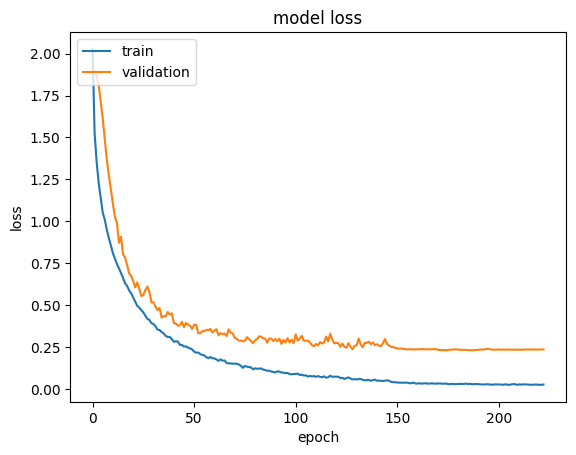

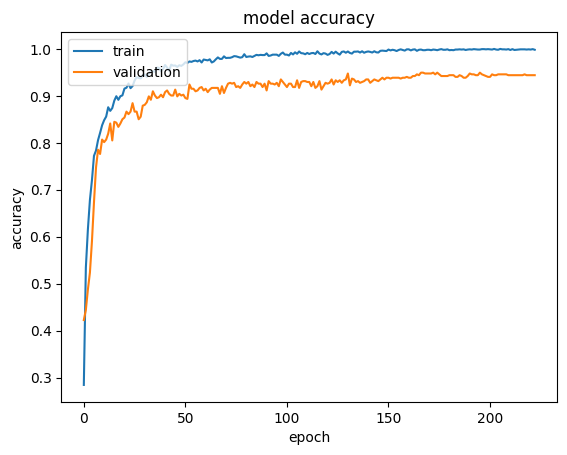

gries
Epoch 1/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 508ms/step - accuracy: 0.2122 - loss: 2.1896 - val_accuracy: 0.4946 - val_loss: 1.9144 - learning_rate: 0.0010
Epoch 2/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5004 - loss: 1.6056 - val_accuracy: 0.5144 - val_loss: 1.8687 - learning_rate: 0.0010
Epoch 3/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6111 - loss: 1.3940 - val_accuracy: 0.5686 - val_loss: 1.8180 - learning_rate: 0.0010
Epoch 4/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6763 - loss: 1.2556 - val_accuracy: 0.5957 - val_loss: 1.7400 - learning_rate: 0.0010
Epoch 5/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7091 - loss: 1.1828 - val_accuracy: 0.6318 - val_loss: 1.6314 - learning_rate: 0.0010
Epoch 6/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7432 - loss: 1.0904 - val_accuracy: 0.6733 - val_loss: 1.5352 - learning_rate: 0.0010
Epoch 7/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7739 - 

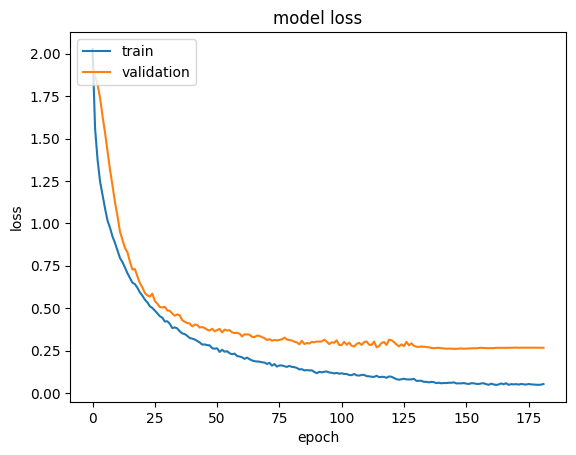

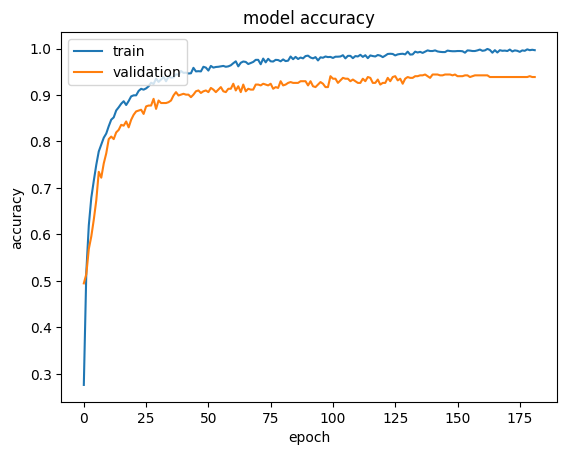

problem_code
Epoch 1/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 314ms/step - accuracy: 0.1866 - loss: 2.2493 - val_accuracy: 0.2365 - val_loss: 2.0050 - learning_rate: 0.0010
Epoch 2/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3640 - loss: 1.8247 - val_accuracy: 0.2617 - val_loss: 2.0070 - learning_rate: 0.0010
Epoch 3/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4335 - loss: 1.7335 - val_accuracy: 0.2635 - val_loss: 1.9663 - learning_rate: 0.0010
Epoch 4/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5172 - loss: 1.5931 - val_accuracy: 0.2581 - val_loss: 1.9315 - learning_rate: 0.0010
Epoch 5/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5301 - loss: 1.5101 - val_accuracy: 0.2744 - val_loss: 1.8725 - learning_rate: 0.0010
Epoch 6/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5651 - loss: 1.4281 - val_accuracy: 0.3159 - val_loss: 1.8255 - learning_rate: 0.0010
Epoch 7/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5

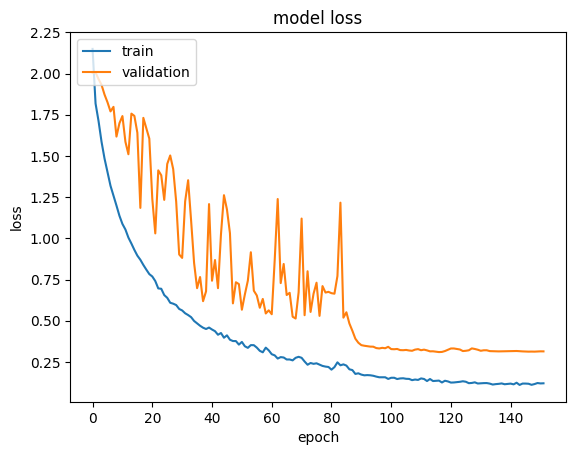

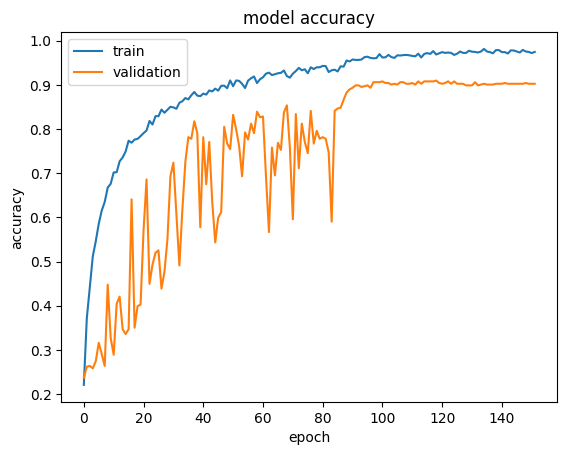

code
Epoch 1/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.1652 - loss: 2.3085 - val_accuracy: 0.0776 - val_loss: 2.1152 - learning_rate: 0.0010
Epoch 2/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3429 - loss: 1.8653 - val_accuracy: 0.0794 - val_loss: 2.1155 - learning_rate: 0.0010
Epoch 3/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4508 - loss: 1.7109 - val_accuracy: 0.1913 - val_loss: 2.0043 - learning_rate: 0.0010
Epoch 4/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4761 - loss: 1.6308 - val_accuracy: 0.3574 - val_loss: 1.9296 - learning_rate: 0.0010
Epoch 5/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5357 - loss: 1.5287 - val_accuracy: 0.4458 - val_loss: 1.8497 - learning_rate: 0.0010
Epoch 6/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5507 - loss: 1.4359 - val_accuracy: 0.3845 - val_loss: 1.7484 - learning_rate: 0.0010
Epoch 7/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5910 - los

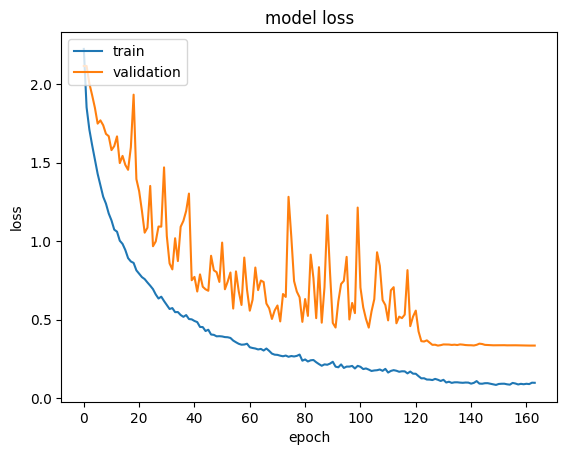

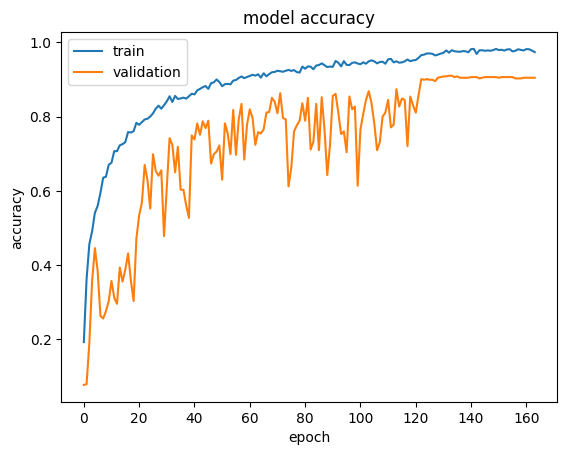

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from time import time
#tensorflow random state
tf.random.set_seed(2023)

times=[]
max_accuracies=[]
max_val_accuracies=[]
max_val_losses=[]
max_losses=[]
learning_rates=[]
Model_Xtrain=[Xp_train,Xcode_train,Xs_train,Xt_train,Xf_train]

for i,my_model in enumerate(models):
  print(models_names[i])

  problem_input=Input((768,))
  start_input=Input((768,))
  trass_input=Input((768,))
  final_input=Input((768,))

  patience=35

  my_model.compile(loss='sparse_categorical_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

  es = EarlyStopping(monitor='val_loss', mode='min', patience=patience)

  mc = ModelCheckpoint('/content/drive/MyDrive/UDENAR/ProyectosGrado/Errol/Ginna/Tuning/BestModels/ablationsGRAPH_finall_{0}.keras'.format(models_names[i]), monitor='val_loss', mode='min', save_best_only=True)
  reduce_lr = ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.1,
      patience=patience//2,
      min_lr=1e-9,
      verbose=1
  )
  if(i==1):
    Model_Xtrain=[Xp_train,Xs_train,Xt_train,Xf_train]
  if(i==2):
    Model_Xtrain=[Xcode_train,Xs_train,Xt_train,Xf_train]
  if(i==3):
    Model_Xtrain=[Xs_train,Xt_train,Xf_train]
  if(i==4):
    Model_Xtrain=[Xp_train,Xcode_train]
  if(i==5):
    Model_Xtrain=[Xcode_train]


  time1=time()
  history=my_model.fit(Model_Xtrain,y_train,batch_size=100,epochs=1000,
            validation_split=0.2,callbacks=[es, mc,reduce_lr])
  time2=time()

  df_histories=pd.DataFrame(history.history)
  df_histories.to_csv('/content/drive/MyDrive/UDENAR/ProyectosGrado/Errol/Ginna/Tuning/BestModels/ablations_best_finallGRAPH_{0}.csv'.format(models_names[i]))

  times.append(time2-time1)

  max_accuracies.append(max(history.history['accuracy']))
  max_val_accuracies.append(max(history.history['val_accuracy']))
  max_val_losses.append(max(history.history['val_loss']))
  max_losses.append(max(history.history['loss']))
  learning_rates.append(min(history.history['learning_rate']))

  print(f"{patience}")
  print("times=",time2-time1)
  print("max_val_accuracy",max(history.history['val_accuracy']))
  print("max_accuracy",max(history.history['accuracy']))


  print("max_val_loss",max(history.history['val_loss']))
  print("max_loss",max(history.history['loss']))
  print("learning_rate",min(history.history['learning_rate']))
  print("\n")
  plot_history(history)





In [ ]:
df_histories=pd.DataFrame({"times":times,"max_accuracies":max_accuracies,"max_val_accuracies":max_val_accuracies,"max_val_losses":max_val_losses,"max_losses":max_losses,"learning_rates":learning_rates})
#df_histories.to_csv('/content/drive/MyDrive/UDENAR/ProyectosGrado/Errol/Ginna/Tuning/BestModels/ablations_finallGRAPH.csv')

NameError: name 'times' is not defined

In [ ]:
df_histories

,times,max_accuracies,max_val_accuracies,max_val_losses,max_losses,learning_rates
0,105.892587,0.998644,0.942238,1.939351,2.001638,0.000001
1,119.232641,0.999096,0.945848,1.890968,2.005906,0.000001
2,113.070776,1.000000,0.949458,1.906058,2.027656,0.000001
3,89.050469,0.999096,0.944043,1.914414,2.028236,0.000001
4,58.038302,0.981473,0.909747,2.006974,2.149365,0.000001
5,47.330261,0.981925,0.909747,2.115501,2.223933,0.000001


In [ ]:
from sklearn.metrics import matthews_corrcoef, precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

def calculate_mcc_multiclass(y_true, y_pred_probs):
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    # Convertir etiquetas verdaderas one-hot a etiquetas enteras si es necesario
    #y_true_labels = np.argmax(y_true, axis=1) if y_true.ndim > 1 else y_true
    return matthews_corrcoef(y_true, y_pred_labels)

def calculate_auc_pr_multiclass(y_true, y_pred_probs, average='macro'):
    n_classes = y_pred_probs.shape[1]
    #y_true_labels = np.argmax(y_true, axis=1) if y_true.ndim > 1 else y_true
    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    auc_pr_list = []
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
        auc_pr_list.append(auc(recall, precision))

    if average == 'macro':
        return np.mean(auc_pr_list)
    elif average == 'weighted':
        class_counts = y_true_bin.sum(axis=0)
        return np.average(auc_pr_list, weights=class_counts)
    else:
        return auc_pr_list


In [ ]:
category=np.array([
    'Initial state',
    'Final state',
    'State transformation',
    'Initial state, Final state',
    'Initial state, State transformation',
    'Final state, State transformation',
    'Initial state, Final state, State transformation'

])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix

def plot_clasificationreport(report):

    df_report = pd.DataFrame(report).transpose()

    # Remove 'accuracy', 'macro avg', and 'weighted avg' rows
    #df_report = df_report.drop(labels=['accuracy', 'macro avg', 'weighted avg'], axis=0)

    # Remove 'support' column
    df_report = df_report.drop(labels=['support'], axis=1)

    # Plot the classification report
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_report, annot=True, cmap='Blues', fmt=".2f")
    plt.title('Classification Report ')
    plt.xlabel('Metrics')
    plt.ylabel('Classes')
    plt.show()

def plot_precisionrecall_curve(ytest,yp):
  lb = LabelBinarizer()
  ytest_binarized = lb.fit_transform(ytest)
  n_classes = ytest_binarized.shape[1]

  # Calculate precision and recall for each class
  precision = dict()
  recall = dict()
  average_precision = dict()
  for i in range(n_classes):
      precision[i], recall[i], _ = precision_recall_curve(ytest_binarized[:, i], yp[:, i])
      average_precision[i] = auc(recall[i], precision[i])

  # Plot Precision-Recall curve for each class and AUC
  plt.figure(figsize=(10, 8))
  for i in range(n_classes):
      plt.plot(recall[i], precision[i], lw=2,
              label=f'Class {category[i]} (AUC = {average_precision[i]:0.2f})')

  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title("Precision-Recall Curve for Multi-class Classification")
  plt.legend(loc="lower left")
  plt.grid(True)
  plt.show()


problemall
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9443 - loss: 0.2094
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step
accuracy 0.9335260391235352
loss 0.2563779950141907
mcc 0.9112208716968972
auc_pr 0.8975062458787162
time predict 3.3168439865112305


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


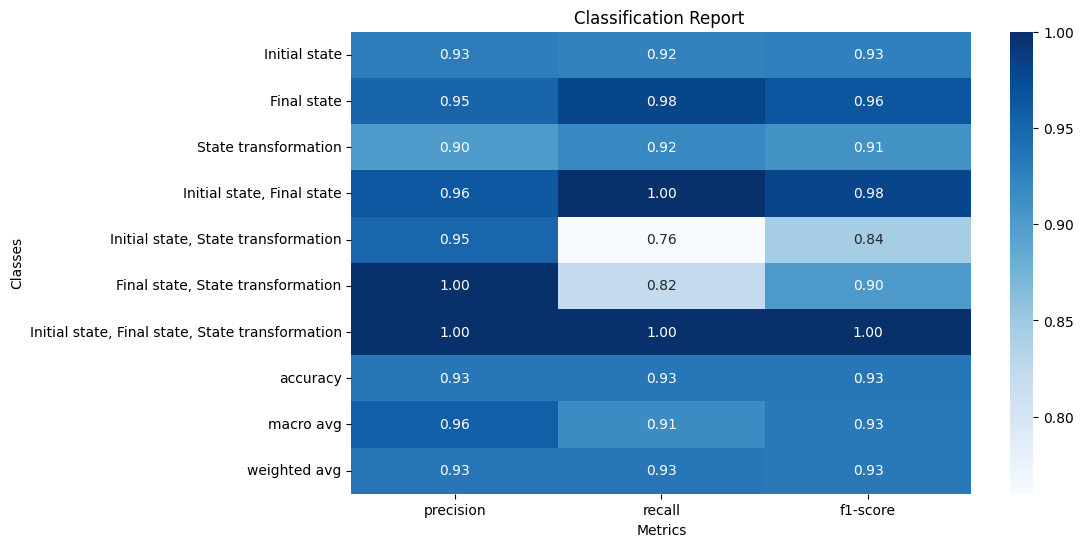

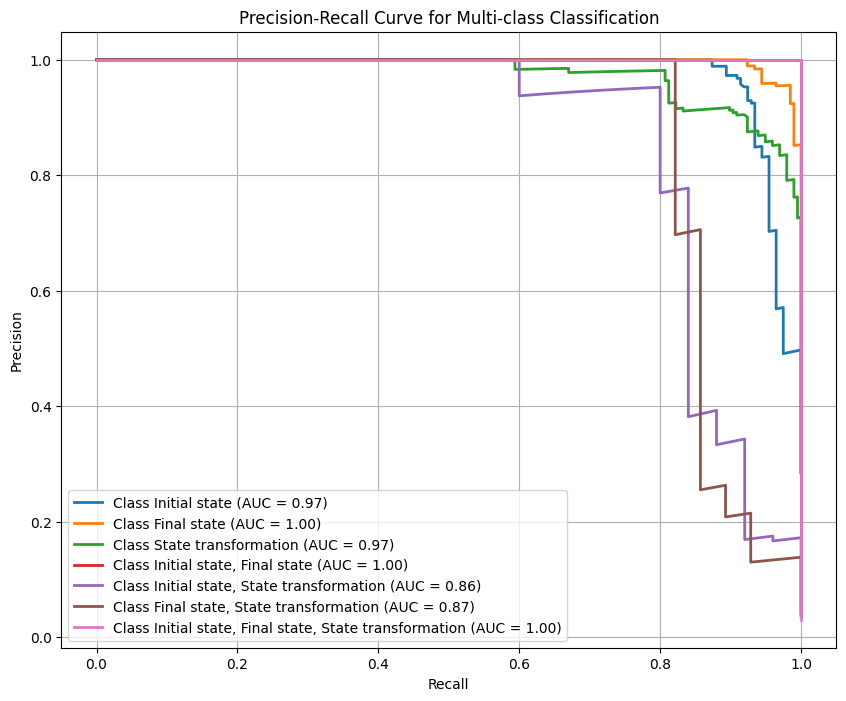

,Initial state,Final state,State transformation,"Initial state, Final state","Initial state, State transformation","Final state, State transformation","Initial state, Final state, State transformation"
Initial state,183,2,13,0,0,0,0
Final state,1,193,2,1,0,0,0
State transformation,11,4,181,0,1,0,0
"Initial state, Final state",0,0,0,26,0,0,0
"Initial state, State transformation",2,0,4,0,19,0,0
"Final state, State transformation",0,4,1,0,0,23,0
"Initial state, Final state, State transformation",0,0,0,0,0,0,21


                                                  precision    recall  f1-score   support

                                   Initial state       0.93      0.92      0.93       198
                                     Final state       0.95      0.98      0.96       197
                            State transformation       0.90      0.92      0.91       197
                      Initial state, Final state       0.96      1.00      0.98        26
             Initial state, State transformation       0.95      0.76      0.84        25
               Final state, State transformation       1.00      0.82      0.90        28
Initial state, Final state, State transformation       1.00      1.00      1.00        21

                                        accuracy                           0.93       692
                                       macro avg       0.96      0.91      0.93       692
                                    weighted avg       0.93      0.93      0.93       692

problem

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


accuracy 0.9349710941314697
loss 0.2790259122848511
mcc 0.9131252459929607
auc_pr 0.8934147164558665
time predict 5.23403787612915


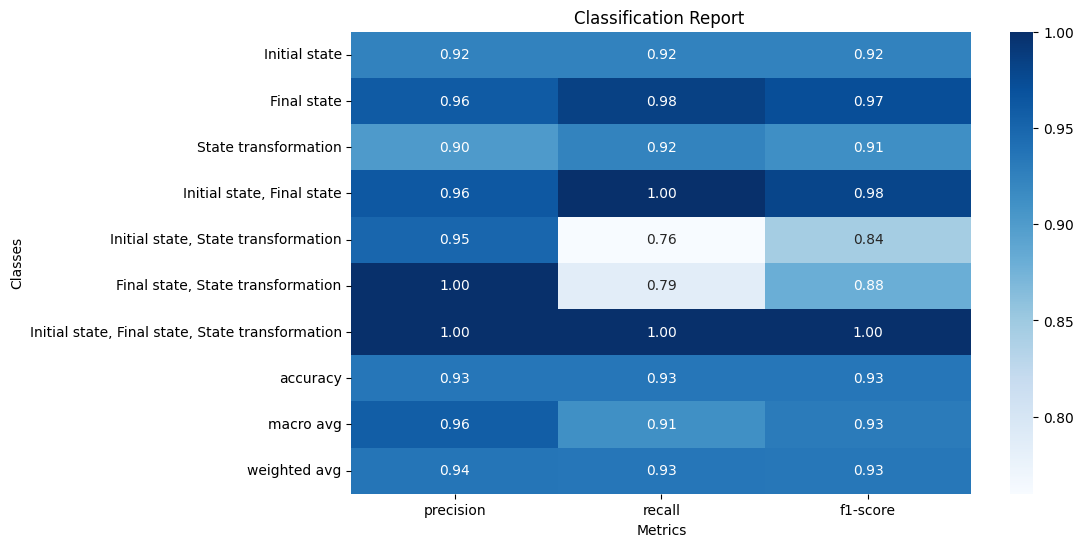

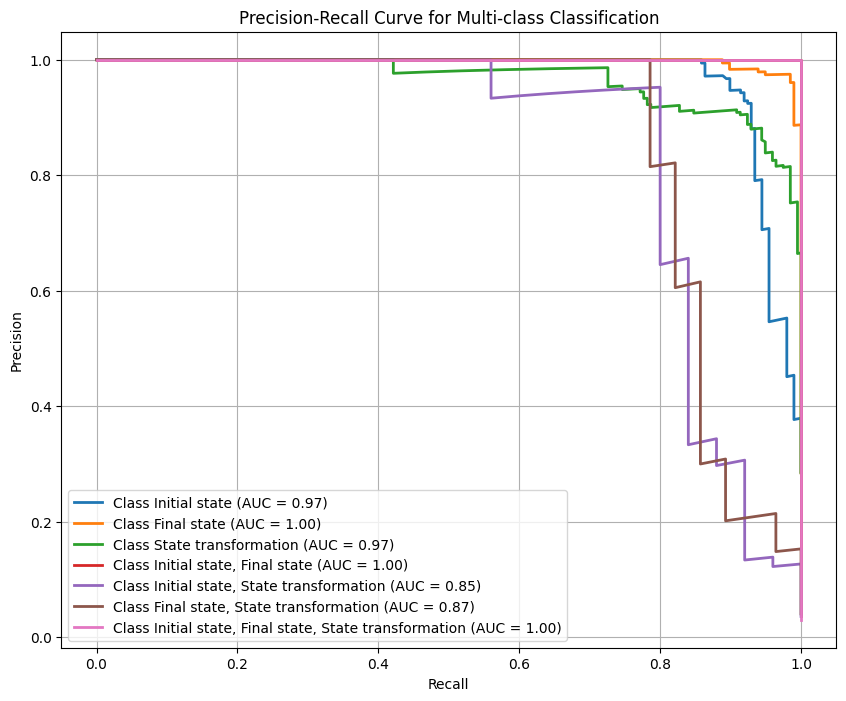

,Initial state,Final state,State transformation,"Initial state, Final state","Initial state, State transformation","Final state, State transformation","Initial state, Final state, State transformation"
Initial state,183,2,13,0,0,0,0
Final state,0,194,2,1,0,0,0
State transformation,12,2,182,0,1,0,0
"Initial state, Final state",0,0,0,26,0,0,0
"Initial state, State transformation",3,0,3,0,19,0,0
"Final state, State transformation",0,4,2,0,0,22,0
"Initial state, Final state, State transformation",0,0,0,0,0,0,21


                                                  precision    recall  f1-score   support

                                   Initial state       0.92      0.92      0.92       198
                                     Final state       0.96      0.98      0.97       197
                            State transformation       0.90      0.92      0.91       197
                      Initial state, Final state       0.96      1.00      0.98        26
             Initial state, State transformation       0.95      0.76      0.84        25
               Final state, State transformation       1.00      0.79      0.88        28
Initial state, Final state, State transformation       1.00      1.00      1.00        21

                                        accuracy                           0.93       692
                                       macro avg       0.96      0.91      0.93       692
                                    weighted avg       0.94      0.93      0.93       692

code_gr

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


accuracy 0.9306358098983765
loss 0.25626546144485474
mcc 0.9074501232615377
auc_pr 0.8972964812152249
time predict 5.347229719161987


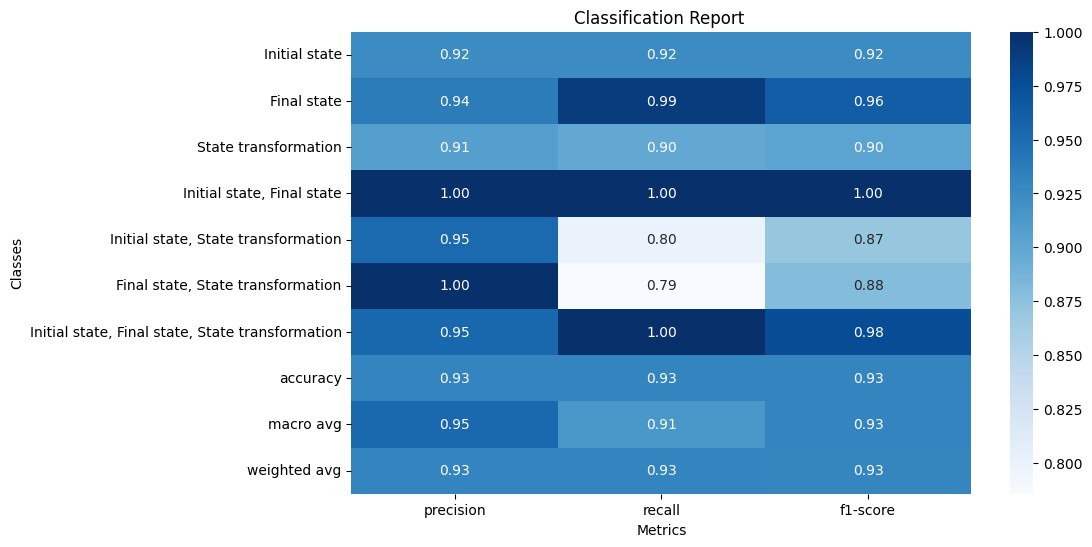

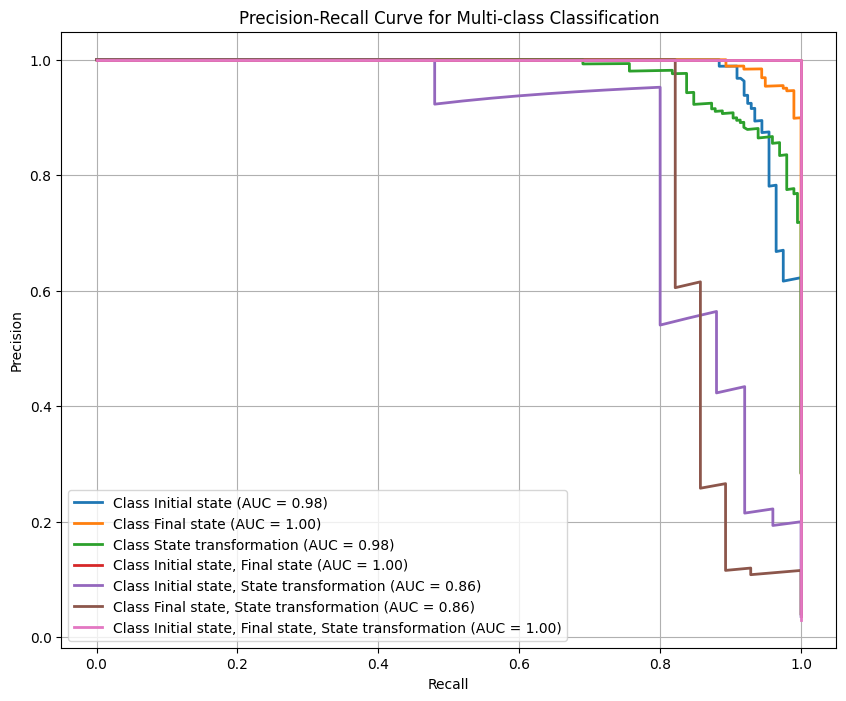

,Initial state,Final state,State transformation,"Initial state, Final state","Initial state, State transformation","Final state, State transformation","Initial state, Final state, State transformation"
Initial state,183,2,13,0,0,0,0
Final state,0,195,2,0,0,0,0
State transformation,13,6,177,0,1,0,0
"Initial state, Final state",0,0,0,26,0,0,0
"Initial state, State transformation",2,0,2,0,20,0,1
"Final state, State transformation",0,5,1,0,0,22,0
"Initial state, Final state, State transformation",0,0,0,0,0,0,21


                                                  precision    recall  f1-score   support

                                   Initial state       0.92      0.92      0.92       198
                                     Final state       0.94      0.99      0.96       197
                            State transformation       0.91      0.90      0.90       197
                      Initial state, Final state       1.00      1.00      1.00        26
             Initial state, State transformation       0.95      0.80      0.87        25
               Final state, State transformation       1.00      0.79      0.88        28
Initial state, Final state, State transformation       0.95      1.00      0.98        21

                                        accuracy                           0.93       692
                                       macro avg       0.95      0.91      0.93       692
                                    weighted avg       0.93      0.93      0.93       692

gries
2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


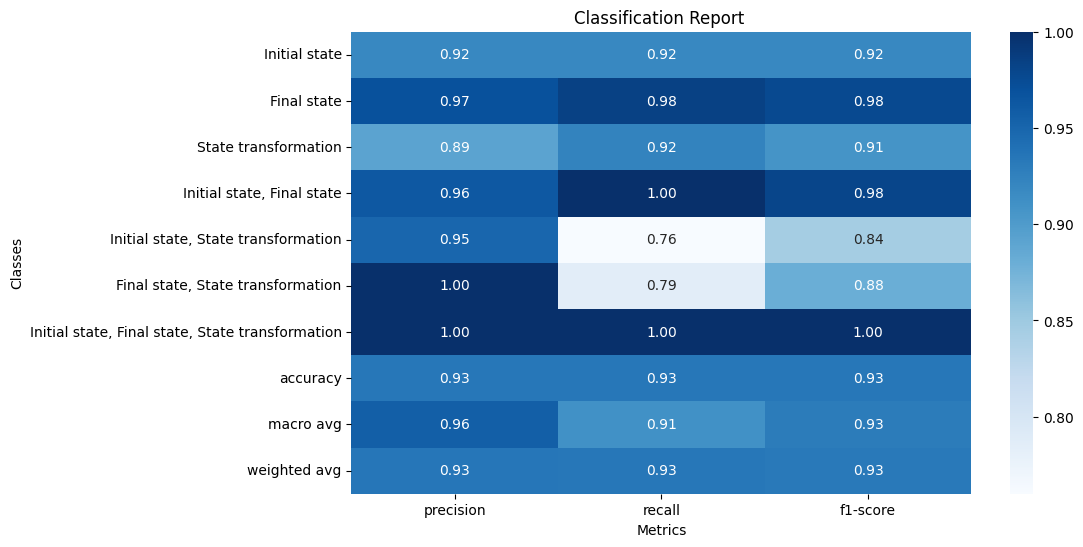

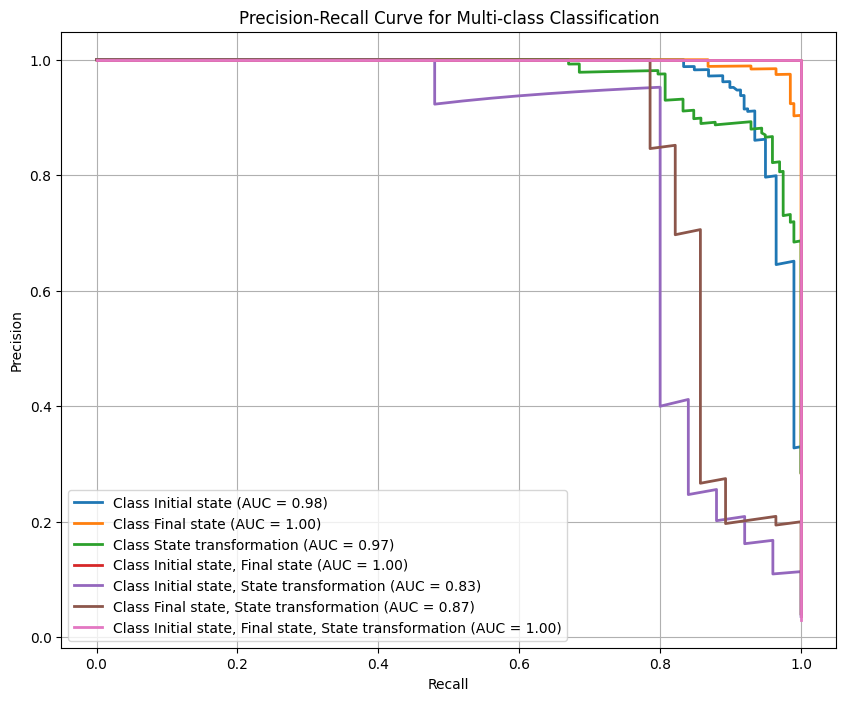

,Initial state,Final state,State transformation,"Initial state, Final state","Initial state, State transformation","Final state, State transformation","Initial state, Final state, State transformation"
Initial state,182,0,16,0,0,0,0
Final state,0,194,2,1,0,0,0
State transformation,13,1,182,0,1,0,0
"Initial state, Final state",0,0,0,26,0,0,0
"Initial state, State transformation",3,0,3,0,19,0,0
"Final state, State transformation",0,5,1,0,0,22,0
"Initial state, Final state, State transformation",0,0,0,0,0,0,21


                                                  precision    recall  f1-score   support

                                   Initial state       0.92      0.92      0.92       198
                                     Final state       0.97      0.98      0.98       197
                            State transformation       0.89      0.92      0.91       197
                      Initial state, Final state       0.96      1.00      0.98        26
             Initial state, State transformation       0.95      0.76      0.84        25
               Final state, State transformation       1.00      0.79      0.88        28
Initial state, Final state, State transformation       1.00      1.00      1.00        21

                                        accuracy                           0.93       692
                                       macro avg       0.96      0.91      0.93       692
                                    weighted avg       0.93      0.93      0.93       692

problem

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


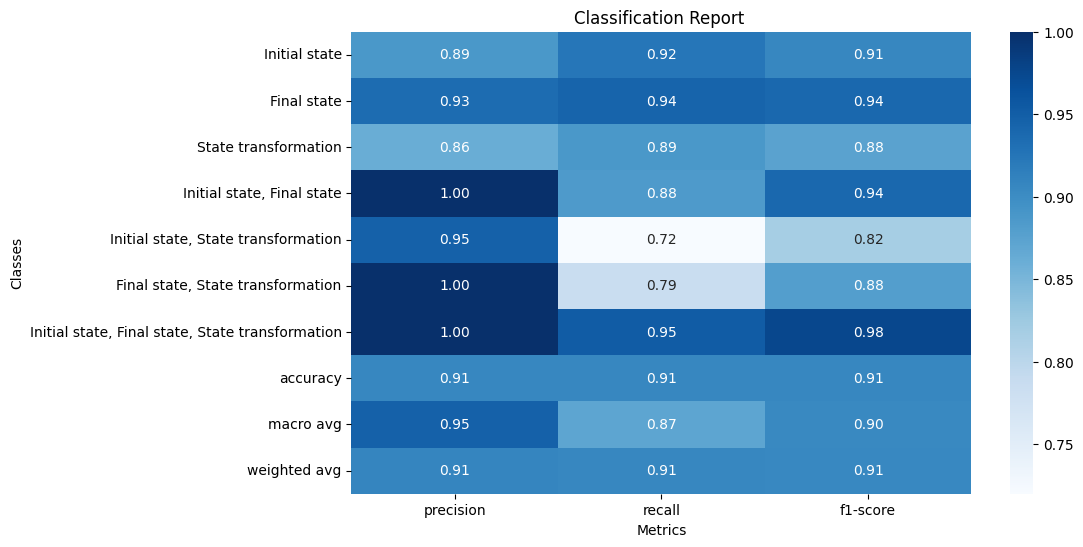

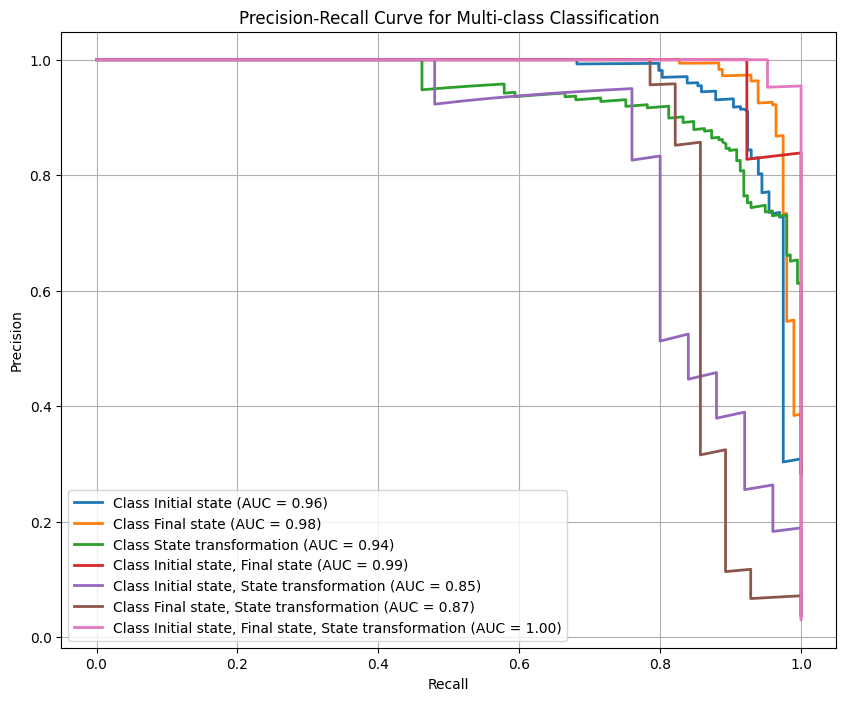

,Initial state,Final state,State transformation,"Initial state, Final state","Initial state, State transformation","Final state, State transformation","Initial state, Final state, State transformation"
Initial state,183,0,15,0,0,0,0
Final state,7,186,4,0,0,0,0
State transformation,14,7,175,0,1,0,0
"Initial state, Final state",1,2,0,23,0,0,0
"Initial state, State transformation",1,2,4,0,18,0,0
"Final state, State transformation",0,2,4,0,0,22,0
"Initial state, Final state, State transformation",0,0,1,0,0,0,20


                                                  precision    recall  f1-score   support

                                   Initial state       0.89      0.92      0.91       198
                                     Final state       0.93      0.94      0.94       197
                            State transformation       0.86      0.89      0.88       197
                      Initial state, Final state       1.00      0.88      0.94        26
             Initial state, State transformation       0.95      0.72      0.82        25
               Final state, State transformation       1.00      0.79      0.88        28
Initial state, Final state, State transformation       1.00      0.95      0.98        21

                                        accuracy                           0.91       692
                                       macro avg       0.95      0.87      0.90       692
                                    weighted avg       0.91      0.91      0.91       692

code
22

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


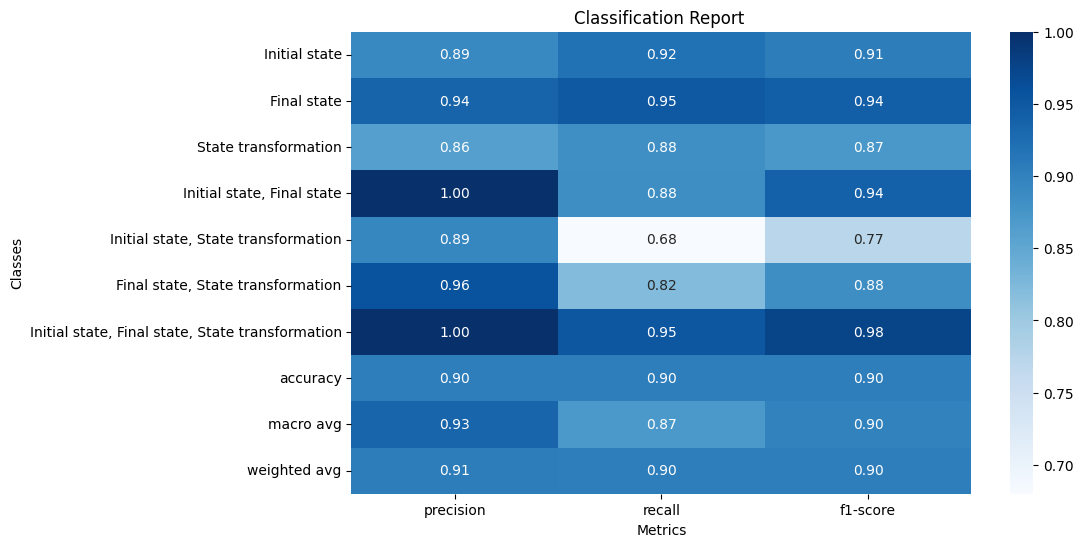

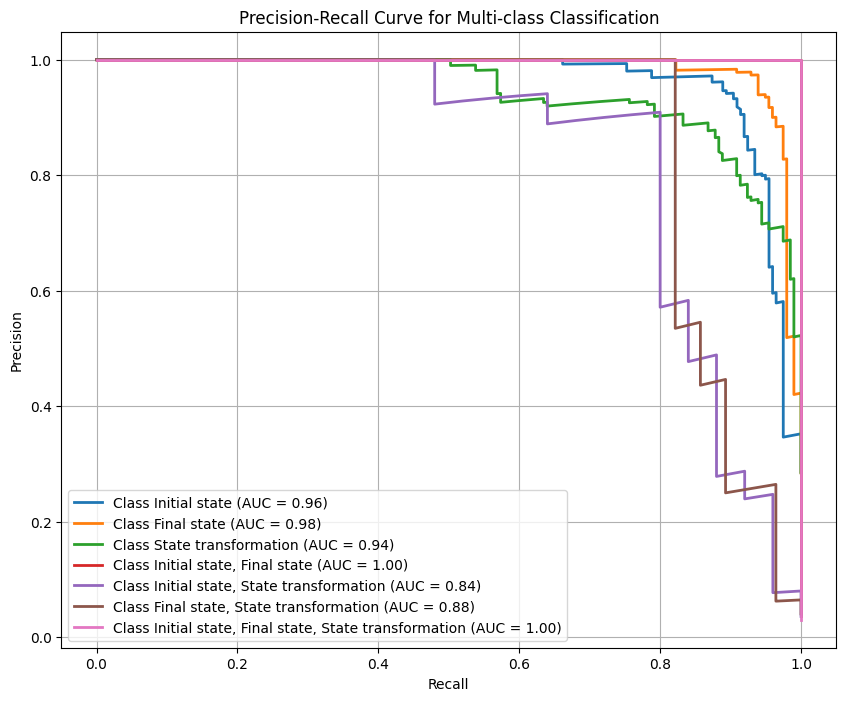

,Initial state,Final state,State transformation,"Initial state, Final state","Initial state, State transformation","Final state, State transformation","Initial state, Final state, State transformation"
Initial state,182,0,16,0,0,0,0
Final state,5,187,5,0,0,0,0
State transformation,15,6,174,0,2,0,0
"Initial state, Final state",1,2,0,23,0,0,0
"Initial state, State transformation",1,2,4,0,17,1,0
"Final state, State transformation",0,3,2,0,0,23,0
"Initial state, Final state, State transformation",0,0,1,0,0,0,20


                                                  precision    recall  f1-score   support

                                   Initial state       0.89      0.92      0.91       198
                                     Final state       0.94      0.95      0.94       197
                            State transformation       0.86      0.88      0.87       197
                      Initial state, Final state       1.00      0.88      0.94        26
             Initial state, State transformation       0.89      0.68      0.77        25
               Final state, State transformation       0.96      0.82      0.88        28
Initial state, Final state, State transformation       1.00      0.95      0.98        21

                                        accuracy                           0.90       692
                                       macro avg       0.93      0.87      0.90       692
                                    weighted avg       0.91      0.90      0.90       692



In [ ]:
from tensorflow import keras
from time import time
accuracies_predict=[]
loss_predict=[]
times_predict=[]
mccs_predict=[]
aucpr_predict=[]

Model_Xtest=[Xp_test,Xcode_test,Xs_test,Xt_test,Xf_test]
for i,my_model in enumerate(models_names):
  print(my_model)
  model=keras.models.load_model('/content/drive/MyDrive/UDENAR/ProyectosGrado/Errol/Ginna/Tuning/BestModels/ablationsGRAPH_finall_{0}.keras'.format(models_names[i]))
  if(i==1):
    Model_Xtest=[Xp_test,Xs_test,Xt_test,Xf_test]
  if(i==2):
    Model_Xtest=[Xcode_test,Xs_test,Xt_test,Xf_test]
  if(i==3):
    Model_Xtest=[Xs_test,Xt_test,Xf_test]
  if(i==4):
    Model_Xtest=[Xp_test,Xcode_test]
  if(i==5):
    Model_Xtest=[Xcode_test]

  evaluate=model.evaluate(Model_Xtest,y_test)

  t1=time()
  y_pred=model.predict(Model_Xtest)
  t2=time()
  mcc=calculate_mcc_multiclass(y_test, y_pred)
  auc_pr=calculate_auc_pr_multiclass(y_test, y_pred)

  times_predict.append(t2-t1)
  accuracies_predict.append(evaluate[1])
  loss_predict.append(evaluate[0])
  mccs_predict.append(mcc)
  aucpr_predict.append(auc_pr)


  accuracy=evaluate[1]
  loss=evaluate[0]

  print("accuracy",accuracy)
  print("loss",loss)
  print("mcc",mcc)
  print("auc_pr",auc_pr)
  print("time predict",t2-t1)
  report=classification_report(y_test,y_pred.argmax(axis=1),target_names=category,output_dict=True)
  plot_clasificationreport(report)
  plot_precisionrecall_curve(y_test,y_pred)
  cm=confusion_matrix(y_test,y_pred.argmax(axis=1))
  df_confusion = pd.DataFrame(cm, index=category, columns=category)
  display(df_confusion)

  print(classification_report(y_test,y_pred.argmax(axis=1),target_names=category))

In [ ]:
df_histories['accuracies_predict']=accuracies_predict
df_histories['loss_predict']=loss_predict
df_histories['times_predict']=times_predict
df_histories['mccs']=mccs_predict
df_histories['aucpr']=aucpr_predict
df_histories.to_csv('/content/drive/MyDrive/UDENAR/ProyectosGrado/Errol/Ginna/Tuning/BestModels/early_best_finall_predictGRAPH.csv')

In [ ]:
df_histories['model']=models_names

In [ ]:
df_histories

,times,max_accuracies,max_val_accuracies,max_val_losses,max_losses,learning_rates,accuracies_predict,loss_predict,times_predict,mccs,aucpr,model
0,118.709888,0.998855,0.951145,1.870439,1.885224,1.000000e-05,0.927961,0.300147,2.617314,0.903226,0.869809,problemall
1,116.361754,0.996947,0.948092,1.845734,1.920276,1.000000e-06,0.913309,0.322306,1.661119,0.884063,0.866431,problem_gries
2,120.137696,1.000000,0.952672,1.897879,1.873279,1.000000e-07,0.927961,0.287234,1.625784,0.903560,0.875402,code_gries
3,73.079383,0.993130,0.951145,1.922092,1.906677,1.000000e-05,0.915751,0.319601,1.329534,0.887130,0.863842,gries
4,68.535003,0.987786,0.935878,1.956521,2.046659,1.000000e-06,0.924298,0.306152,1.104980,0.898344,0.870057,problem_code
5,69.457429,0.990076,0.945038,1.960772,2.067834,1.000000e-07,0.923077,0.325451,0.834566,0.896819,0.873375,code


In [ ]:
df_histories[(df_histories['aucpr']>0.87)]

,times,max_accuracies,max_val_accuracies,max_val_losses,max_losses,learning_rates,accuracies_predict,loss_predict,times_predict,mccs,aucpr,model
2,120.137696,1.000000,0.952672,1.897879,1.873279,1.000000e-07,0.927961,0.287234,1.625784,0.903560,0.875402,code_gries
4,68.535003,0.987786,0.935878,1.956521,2.046659,1.000000e-06,0.924298,0.306152,1.104980,0.898344,0.870057,problem_code
5,69.457429,0.990076,0.945038,1.960772,2.067834,1.000000e-07,0.923077,0.325451,0.834566,0.896819,0.873375,code


In [ ]:
df_histories[(df_histories['aucpr']>0.87)&(df_histories['max_accuracies']-df_histories['max_val_accuracies']<0.06)]

,times,max_accuracies,max_val_accuracies,max_val_losses,max_losses,learning_rates,accuracies_predict,loss_predict,times_predict,mccs,aucpr,model
2,120.137696,1.000000,0.952672,1.897879,1.873279,1.000000e-07,0.927961,0.287234,1.625784,0.903560,0.875402,code_gries
4,68.535003,0.987786,0.935878,1.956521,2.046659,1.000000e-06,0.924298,0.306152,1.104980,0.898344,0.870057,problem_code
5,69.457429,0.990076,0.945038,1.960772,2.067834,1.000000e-07,0.923077,0.325451,0.834566,0.896819,0.873375,code


Early stoping 40 the best